# Applied Machine Learning

## Assignment9 - ShunFai Lee

In [20]:
#import all needed libraries
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate,KFold
from sklearn.metrics import confusion_matrix, make_scorer, recall_score, precision_score, accuracy_score,r2_score, adjusted_rand_score
from sklearn.metrics.cluster import contingency_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import neural_network, tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.feature_selection import SelectFromModel

In [3]:
# function to drop duplicate rows
def drop_dup(df:pd.DataFrame):
    df["is_duplicate"]= df.duplicated()
    index_to_drop = df[df['is_duplicate']==True].index
    if len(index_to_drop)==0:
        df.drop(columns='is_duplicate', inplace=True)
    else:
        df.drop(index_to_drop, inplace=True)
        df.drop(columns='is_duplicate', inplace=True)

#function to drop rows with less than half of features available
def drop_tooManyNA(df:pd.DataFrame):
    df.dropna(thresh=len(df.columns)//2,inplace=True)

### Question 1:
#### Dataset exploration of the "Credit Card Fraud Detection" from Kaggle

In [7]:
#load data set
dataset1 = pd.read_csv("creditcard.csv")

print("Credit Card Fraud Detection dataset")
print(f'total rows_N={len(dataset1)}, features_M={len(dataset1.columns)}\n')
print(f'Columns:\n{dataset1.columns}\n')

# Sanity check
print(f'checking duplicate entries:')
dataset1['duplicate']=dataset1.duplicated()
dup_len = len(dataset1[dataset1['duplicate']==True])
print(f'Number of duplicate: {dup_len}')
if dup_len>0:
    drop_dup(dataset1)
    print(f'Dropped {dup_len} rows for duplicate\n')
dataset1=dataset1.drop(columns=['duplicate'])    

print(f'checking null entries:')
null_stat = dataset1.isnull().sum()
total_null = 0
for c in dataset1.columns:
    if null_stat[c]>0:
        total_null+=null_stat[c]
        print(f'number of null values at {c}: {null_stat[c]}')
if total_null==0:
    print("No null values\n")
dataset1=dataset1.dropna()

print(f"Unique labels of dataset:")
print(dataset1[dataset1.columns[-1]].value_counts(),"\n")

Credit Card Fraud Detection dataset
total rows_N=284807, features_M=31

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

checking duplicate entries:
Number of duplicate: 1081
Dropped 1081 rows for duplicate

checking null entries:
No null values

Unique labels of dataset:
Class
0    284013
1       486
Name: count, dtype: int64 



1081 rows of duplicate data are deleted.

In [5]:
print('Number and type of each type of features:')
for t in dataset1.dtypes.unique():
    print(f'Number of features of type {t}:')
    print(dataset1.columns[dataset1.dtypes==t].values)

Number and type of each type of features:
Number of features of type float64:
<StringArray>
[  'Time',     'V1',     'V2',     'V3',     'V4',     'V5',     'V6',
     'V7',     'V8',     'V9',    'V10',    'V11',    'V12',    'V13',
    'V14',    'V15',    'V16',    'V17',    'V18',    'V19',    'V20',
    'V21',    'V22',    'V23',    'V24',    'V25',    'V26',    'V27',
    'V28', 'Amount']
Length: 30, dtype: str
Number of features of type int64:
<StringArray>
['Class']
Length: 1, dtype: str


There are 30 features and all of them are of float type. The class column is already in integers.

Then look at the ranges of values at different features:

In [6]:
num_cols = dataset1.columns[dataset1.dtypes=='float64']
value_ranges = {c:{'min':dataset1[c].min(),'max':dataset1[c].max()} for c in num_cols}
for k in value_ranges:
    print(f'{k:30}, min:{value_ranges[k]['min']:15.3f}, max:{value_ranges[k]['max']:15.3f}')

Time                          , min:          0.000, max:     172792.000
V1                            , min:        -56.408, max:          2.455
V2                            , min:        -72.716, max:         22.058
V3                            , min:        -48.326, max:          9.383
V4                            , min:         -5.683, max:         16.875
V5                            , min:       -113.743, max:         34.802
V6                            , min:        -26.161, max:         73.302
V7                            , min:        -43.557, max:        120.589
V8                            , min:        -73.217, max:         20.007
V9                            , min:        -13.434, max:         15.595
V10                           , min:        -24.588, max:         23.745
V11                           , min:         -4.797, max:         12.019
V12                           , min:        -18.684, max:          7.848
V13                           , min:         -5.792

Now plot the histogram of each features

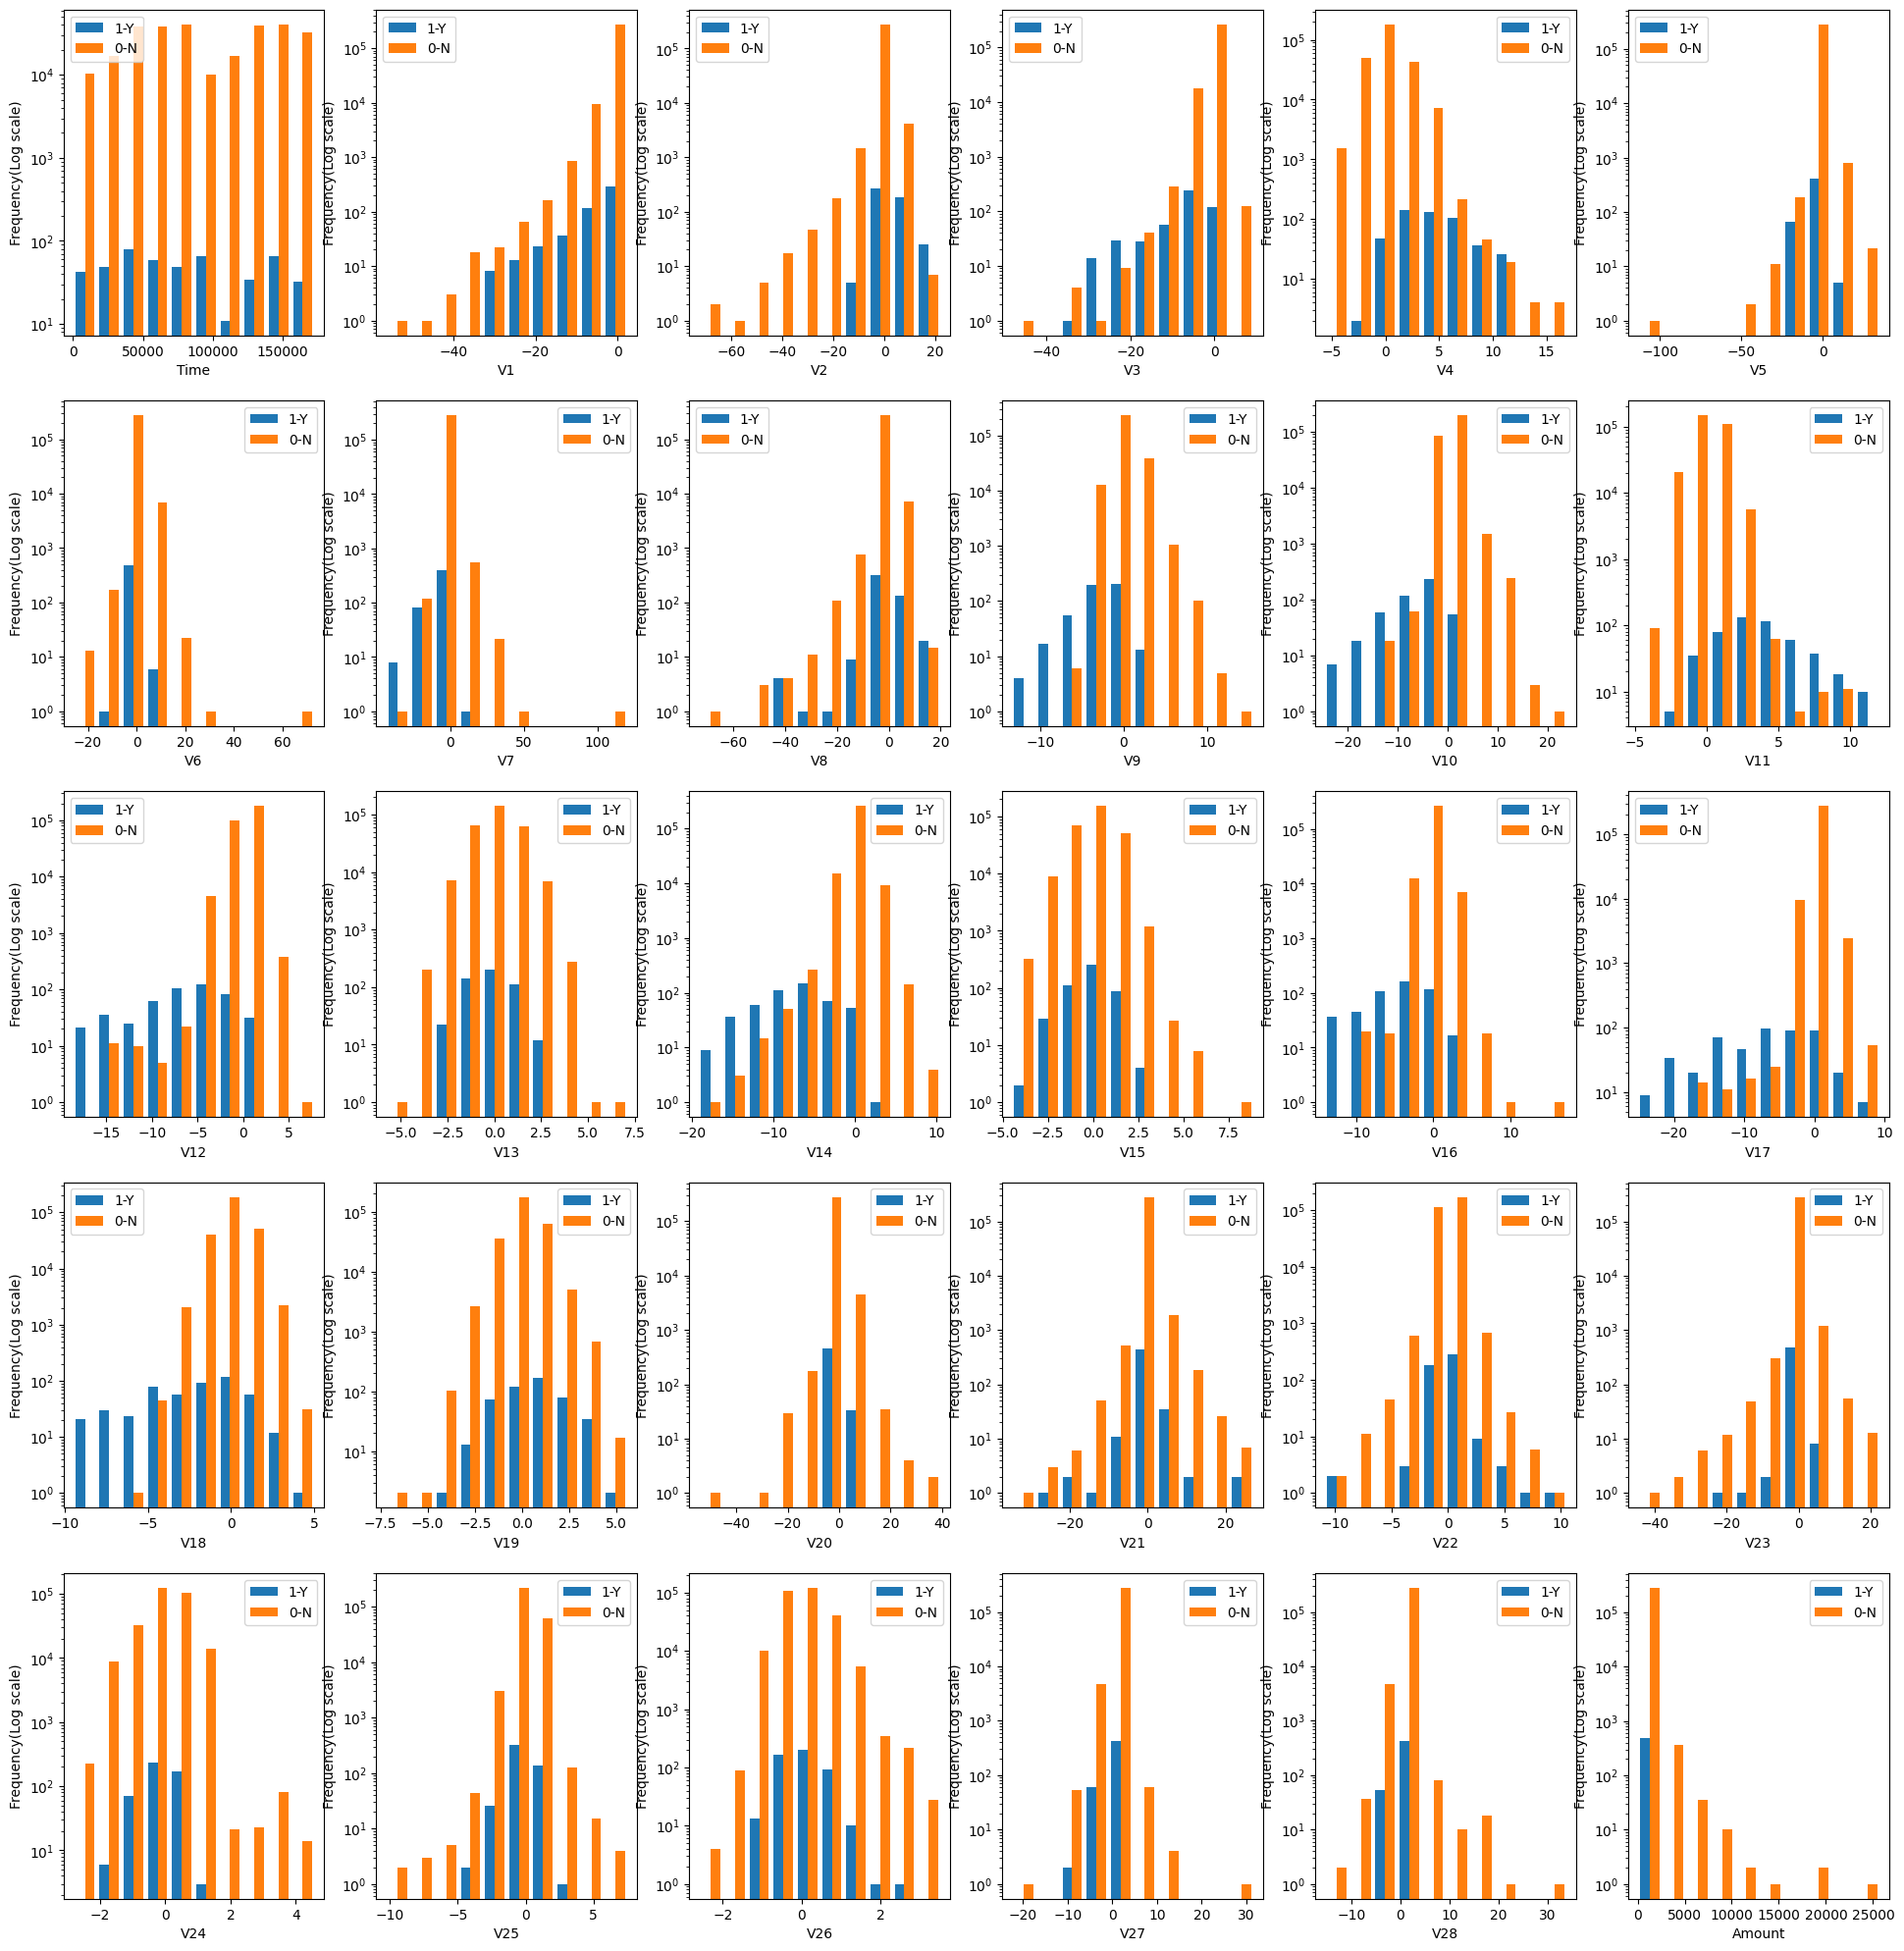

In [ ]:
#plot histogram
X_to_plot = dataset1.drop(columns='Class')
Y_to_plot = dataset1['Class']
plot_per_row = 6
n_rows = (len(X_to_plot.columns)+plot_per_row-1)//plot_per_row
plot_per_row = 6

_, ax = plt.subplots(nrows=n_rows, ncols=plot_per_row, figsize=(24, 5*n_rows))
cols = X_to_plot.columns
# Plot each feature of their own
for i,c in enumerate(cols):
    x = i%plot_per_row
    y = i//plot_per_row   
    ax[y,x].set_xlabel(c)
    ax[y,x].set_ylabel("Frequency(Log scale)")
    
    min = X_to_plot[c].min()
    max = X_to_plot[c].max()
    #ax[y,x].set_xticks([X[c].min(), X[c].max()])
    #ax[y,x].tick_params(axis='x', labelrotation=45)
    #ax[y,x].hist(X[c], bins=10, edgecolor='black',label=f"Min: {min:.2f}\nMax: {max:.2f}")
    ax[y,x].hist([X_to_plot[Y_to_plot==1][c],X_to_plot[Y_to_plot==0][c]], label=['1-Y','0-N'])
    ax[y,x].set_yscale("log")
    ax[y,x].legend()

plt.show()

### Question 2:
#### Class balance and evaluation metric

In [11]:
print(f"Unique labels of dataset:")
print(dataset1[dataset1.columns[-1]].value_counts(),"\n")

Unique labels of dataset:
Class
0    284013
1       486
Name: count, dtype: int64 



As shown on above printout, there are 284013 rows that are of class 0 and only 486 rows are of class 1. The dataset is extremely unbalanced. Therefore it matter more to identify the class 1 as much as possible than the other class. Accuracy in this case will be very misleading as a model can achieve very high accuracy and miss all class 1 at the same time. F1 score will be a more reliable metric for this dataset as it reflects more on models' ability to identify the possitive class.

### Question 3:
#### Justification for normalization / standardization

While most of features have very similar ranges of values, two features, "time" and "amount" have exceptionally larger value ranges and maximum values. Although histogram of "time" feature does not indicate any obvious difference in distribution for both classes, "amount" feature shows some difference that might be important for the model. 

Without scaling by standardization or normalization, the model will not converge well, due to the fluctuation of weight for this particular feature because of the large value. Also, it can avoid the model being dominated by such large valued feature.

Therefore, standardization is necessary. A pipeline is used to setup the standardization instead of preprocessing instantly.

In [ ]:
#separate targets and features, and drop the unnecessary columns
X = dataset1.drop(columns='Class')
Y = dataset1['Class']

#all columns have float type and need standardization
categorical_cols1 = dataset1.columns[dataset1.dtypes=='float64']

#set up the pipelines
cat_transform1 = Pipeline([('scaler',StandardScaler())])

#set up the transformer, which is just standardization
preprocessor = ColumnTransformer(transformers=[('categorical1',cat_transform1,categorical_cols1)],
                                               verbose_feature_names_out=True)




### Question 4:
#### classification performance on 50/50 split of SVC, DecisionTreeClassifier, MLPClassifier and RandomForest

In [22]:
def all_score_safe(y_true, y_pred):
    # Force a 2x2 matrix even if only 1 class is present
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    # Safe division to prevent divide by 0 on the single-class dataset
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accu = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    f1 = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    
    return {'tpr': tpr, 'fpr': fpr, 'precision': precision, 'accu': accu, 'f1': f1}

#split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5, random_state=0,stratify=Y)

_clf = [SVC(kernel='rbf'),tree.DecisionTreeClassifier(),neural_network.MLPClassifier(),RandomForestClassifier()]
model_result = {}
for c in _clf:
    pipe = make_pipeline(preprocessor,c)
    pipe.fit(X_train,Y_train)
    predictions = pipe.predict(X_test)
    result = all_score_safe(Y_test,predictions)
    model_result.update({c.__class__.__name__:result})

In [25]:
for r in model_result:
    print(f'{r}:F1 score:{model_result[r]['f1']:.2f}')

SVC:F1 score:0.69
DecisionTreeClassifier:F1 score:0.76
MLPClassifier:F1 score:0.85
RandomForestClassifier:F1 score:0.87


The 4 models of SVC, DecisionTreeClassifier, MLPClassifier and RandomForestClassifier, with mostly default setting, are trained. Their classification f1 score are summarized as follows:
|Model|f1 Score|
|---|---|
|SVC|0.69|
|DecisionTreeClassifier|0.76|
|MLPClassifier|0.85|
|Random Forest|0.87| 

The f1 score ranges from 0.69 to 0.87. Neural network model and random forest perform significantly better than support vector classifier and decision tree.

### Question 5:
#### Regularization - of SVC, DecisionTreeClassifier and MLPClassifier

#### SVC

In [97]:
#define parameters for the model
C_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
pipe_svc= Pipeline([('preprocessor',preprocessor),('model',SVC(kernel='rbf',random_state=1))])
#pipe_svc= make_pipeline(preprocessor,SVC(kernel='rbf',random_state=1))
# tune the regularization
param_grid = [{'model__C': C_range}]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
gs = GridSearchCV(estimator=pipe_svc,param_grid=param_grid,scoring='f1',refit=True,cv=cv,n_jobs=-1)
gs.fit(X_train,Y_train)

#extract results
F1 = gs.cv_results_['mean_test_score']

In [147]:
C = gs.cv_results_['param_model__C']
print(f'{"C":>7s}    {"Test F1":>7s}')
for i in range(len(C)):
    print(f'{C[i]:7.1f}   {F1[i]:6.3f}')

best_idx = np.argmax(F1)
best_C = C[best_idx]
best_f1 = F1[best_idx]
print(f'Best inverse regularization parameter C is:{best_C} at F1 score: {best_f1:.4f}')

      C    Test F1
    0.0    0.000
    0.0    0.000
    0.0    0.000
    0.1    0.063
    1.0    0.720
   10.0    0.758
  100.0    0.722
 1000.0    0.696
Best inverse regularization parameter C is:10.0 at F1 score: 0.7585


#### decision tree

In [99]:
#define parameters for the model
#ccp_alpha_range = [0.0, 0.0015, 0.003, 0.006, 0.0125, 0.025, 0.05, 0.1]
ccp_alpha_range = np.linspace(0.0,0.002,10)
pipe_tree= Pipeline([('preprocessor',preprocessor),('model',tree.DecisionTreeClassifier())])
param_grid = [{'model__ccp_alpha':ccp_alpha_range}]
#use the same cv from svc
gs_tree = GridSearchCV(estimator=pipe_tree,param_grid=param_grid,scoring='f1',refit=True,cv=cv,n_jobs=-1)
gs_tree.fit(X_train,Y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__ccp_alpha': array([0. ..., 0.002 ])}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [146]:
#extract results
F1_tree = gs_tree.cv_results_['mean_test_score']
ccp = gs_tree.cv_results_['param_model__ccp_alpha']

print(f'{"ccp_alpha":>7s}    {"Test F1":>7s}')
for i in range(len(ccp)):
    print(f'{ccp[i]:7.4f}   {F1_tree[i]:6.3f}')

best_idx = np.argmax(F1_tree)
best_ccp_alpha = ccp[best_idx]
best_f1_tree = F1_tree[best_idx]
print(f'Best ccp-alpha pruning constant is:{best_ccp_alpha} at F1 score: {best_f1_tree:.4f}')


ccp_alpha    Test F1
 0.0000    0.731
 0.0002    0.708
 0.0004    0.640
 0.0007    0.640
 0.0009    0.640
 0.0011    0.640
 0.0013    0.640
 0.0016    0.640
 0.0018    0.000
 0.0020    0.000
Best ccp-alpha pruning constant is:0.0 at F1 score: 0.7307


#### MLP classifier

In [101]:
#define parameters for the model

n_alpha = np.linspace(0.00009,0.00012,10).tolist()+[0.0001]

pipe_nn= Pipeline([('preprocessor',preprocessor),('model',neural_network.MLPClassifier(max_iter=500,random_state=42))])
param_grid = [{'model__alpha':n_alpha}]
#use the same cv from svc
gs_nn = GridSearchCV(estimator=pipe_nn,param_grid=param_grid,scoring='f1',refit=True,cv=cv,n_jobs=-1)
gs_nn.fit(X_train,Y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__alpha': [9e-05, 9.333333333333334e-05, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [145]:
#extract results
F1_nn = gs_nn.cv_results_['mean_test_score']
alpha = gs_nn.cv_results_['param_model__alpha']

print(f'{"ccp_alpha":>7s}    {"Test F1":>7s}')
for i in range(len(alpha)):
    print(f'{alpha[i]:7.6f}   {F1_nn[i]:6.4f}')

best_idx = np.argmax(F1_nn)
best_alpha = alpha[best_idx]
best_f1_nn = F1_nn[best_idx]
print(f'Best alpha regularization for neural network is:{best_alpha:.4f} at F1 score: {best_f1_nn:.4f}')

ccp_alpha    Test F1
0.000090   0.8184
0.000093   0.8287
0.000097   0.8290
0.000100   0.8334
0.000103   0.8307
0.000107   0.8279
0.000110   0.8252
0.000113   0.8171
0.000117   0.8203
0.000120   0.8201
0.000100   0.8334
Best alpha regularization for neural network is:0.0001 at F1 score: 0.8334


In [103]:
#classification performance on test split.
optimized_result = {}
all_models = [gs,gs_tree,gs_nn]

for p in all_models:
    predicts = p.predict(X_test)
    result = all_score_safe(Y_test,predicts)
    optimized_result.update({p.best_estimator_.named_steps["model"].__class__.__name__:result})

print("Optimized test set Classification Result:")
for r in optimized_result:
    print(f'{r}:F1 score:{optimized_result[r]['f1']:.2f}')

Optimized test set Classification Result:
SVC:F1 score:0.71
DecisionTreeClassifier:F1 score:0.75
MLPClassifier:F1 score:0.82


The three models are trained with different regularization parameters respectively.
For SVC, best inverse regularization parameter C is at 10.0.
For decision tree, best ccp-alpha pruning constant is at 0.0, which is the default value.
For MLPclassifier, best alpha regularization is at 0.0001, which is also the default value.

As a result, there is improvement on classification performance on test set, with F1 score increase from 0.69 to 0.71 bt setting C=10. Meanwhile, there is no significant change observed on decision tree and neural network, as the best regularization parameter values are just the default parameter. 

### Question 6:
#### Pytorch neural network and performance

In [104]:
import torch

In [112]:
# neural network class from Lecture jupyter notebook
class PyTorchMLP(torch.nn.Module):
    def __init__(self, n_hidden=10, epochs=100, eta=0.001, minibatch_size=50, seed=0):
        super().__init__()
        self.random = np.random.RandomState(seed)  # shuffle mini batches
        self.n_hidden = n_hidden  # size of the hidden layer
        self.epochs = epochs  # number of iterations
        self.eta = eta  # learning rate
        self.minibatch_size = minibatch_size  # size of training batch - 1 would not work
        self.optimizer = None
        self.loss_func = torch.nn.CrossEntropyLoss()
        self.model = None

    def init_layers(self, _M:int, _K:int) -> None:
        # data structure
        self.model = torch.nn.Sequential(
            torch.nn.Linear(_M, self.n_hidden),
            torch.nn.Sigmoid(),
            torch.nn.Linear(self.n_hidden, self.n_hidden),
            torch.nn.Sigmoid(),
            torch.nn.Linear(self.n_hidden, _K),
        )
    
    def predict(self, _X):
        _X = torch.FloatTensor(_X)
        assert self.model is not None
        self.model.eval()
        with torch.no_grad():
            y_pred = np.argmax(self.model(_X), axis=1)
        self.model.train()
        return y_pred.numpy()

    def fit(self, _X_train, _y_train, info=False):
        import sys
        _X_train, _y_train = torch.FloatTensor(_X_train), torch.LongTensor(_y_train)
        n_features= _X_train.shape[1]
        n_output= len(np.unique(_y_train))  # number of class labels
        
        self.init_layers(n_features, n_output)
        self.optimizer = torch.optim.Rprop(self.model.parameters(), lr=self.eta)  # connect model to optimizer

        for i in range(self.epochs):
            indices = np.arange(_X_train.shape[0])
            self.random.shuffle(indices)  # shuffle the data each epoch

            for start_idx in range(0, indices.shape[0] - self.minibatch_size + 1, self.minibatch_size):
                batch_idx = indices[start_idx:start_idx + self.minibatch_size]
                self.optimizer.zero_grad()
                
                net_out = self.model(_X_train[batch_idx])
                
                loss = self.loss_func(net_out, _y_train[batch_idx])
                loss.backward()
                self.optimizer.step()
                
                if info:
                    sys.stderr.write(f"\r{i+1:03d} Loss: {loss.item():6.5f}")
                    sys.stderr.flush()
        return self

In [ ]:

#transform train and test data created in question 4 to pytorch tensor
X_train_tensor = torch.tensor(preprocessor.fit_transform(X_train), dtype=torch.float32)
X_test_tensor =torch.tensor(preprocessor.transform(X_test), dtype=torch.float32)


Use a 10-fold CV on the training set to find a good batch sizes and layer sizes first

In [218]:
#set up all batch size and layer size
batch_size = [2000,5000,10000,20000,40000]
layer_size = np.arange(20,45,5).tolist()
result_nn_pytorch_test={b:{l:0.0 for l in layer_size} for b in batch_size}
#set up the stratified 10-fold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
for b in batch_size:
    for l in layer_size:
        result = {'tpr':[],
                    'fpr':[],
                    'precision':[],
                    'accu':[],
                    'f1':[]}

        MLP10CV_test = PyTorchMLP(n_hidden=l, epochs=100, eta=0.0001, minibatch_size=b)

        for train_index, test_index in kf.split(X_train_tensor, Y_train.values):
            X_train_tensor_i = X_train_tensor[train_index]
            Y_train_i = Y_train.values[train_index]
            X_test_tensor_i = X_train_tensor[test_index]
            Y_test_i = Y_train.values[test_index]
            
            MLP10CV_test.fit(X_train_tensor_i,Y_train_i)

            MLP_pred = MLP10CV_test.predict(X_test_tensor_i)
            
            MLP_score = all_score_safe(Y_test_i, MLP_pred)
            for k in MLP_score:
                result[k].append(MLP_score[k])

        result_nn_pytorch_test[b][l]=np.array(result['f1']).mean()

In [222]:
print("pytorch MLPclassifier training set 10-fold CV Result F1 score\non different batch and layer size:")
print(f'{"batch size":<11s}',end="")
for s in layer_size:
    print(f'{s:<8}',end="")
print()
for k in result_nn_pytorch_test:
    print(f'{k:<10}',end="")
    for k2 in result_nn_pytorch_test[k]:
        print(f'{result_nn_pytorch_test[k][k2]:>7.4f}',end="")
    print()

pytorch MLPclassifier training set 10-fold CV Result F1 score
on different batch and layer size:
batch size 20      25      30      35      40      
2000       0.7998 0.7768 0.7825 0.7977 0.7903
5000       0.7960 0.7935 0.7846 0.7892 0.7995
10000      0.7898 0.7965 0.8010 0.7956 0.7952
20000      0.8029 0.7993 0.8002 0.7997 0.8054
40000      0.7873 0.8028 0.8100 0.8069 0.8064


Best F1 score occurs at batch size = 40000 and layer size = 30.

In [224]:
#create and train the neural network at batch size = 40000 and layer size = 30
mlp1 = PyTorchMLP(n_hidden=30, epochs=100, eta=0.0001, minibatch_size=40000).fit(X_train_tensor,Y_train.values)
predict_nn_pytorch = mlp1.predict(X_test_tensor)
result_nn_pytorch = all_score_safe(Y_test,predict_nn_pytorch)

In [225]:
print("pytorch MLPclassifier test set Classification Result:")
print(f'{result_nn_pytorch['f1']:.4f}')


pytorch MLPclassifier test set Classification Result:
0.8421


A 10-fold CV is scripted to investigate about the optimal batch size and layer size. The F1 score ranges from 0.78 to 0.81, with the best score occurs at batch size 40000 and layer size 30. With this hyperparameter, the pytorch neural network is trained with the train set and the F1 score of the test set is 0.8421, which is some sort of improvement to the neural network in last question, but very close.

### Question 7:
#### Pytorch neural network with dropout

In [140]:
# A derived class to have Dropout
# reference from Lecture
class MLP2(PyTorchMLP):
    def init_layers(self, _M, _K):
        self.model = torch.nn.Sequential(
            torch.nn.Linear(_M, self.n_hidden),
            torch.nn.Sigmoid(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(self.n_hidden, self.n_hidden),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(self.n_hidden, _K),
        )

Use the same hyperparameter discovered from question 6.

In [226]:
#create and train the neural network at each size
mlp1 = MLP2(n_hidden=30, epochs=100, eta=0.0001, minibatch_size=40000).fit(X_train_tensor,Y_train.values)
predict_nn_pytorch = mlp1.predict(X_test_tensor)
result_nn_pytorch_dropout = all_score_safe(Y_test,predict_nn_pytorch)

In [227]:
print("pytorch MLPclassifier with dropout test set Classification Result:")
print(f'{result_nn_pytorch_dropout['f1']:.4f}')

pytorch MLPclassifier with dropout test set Classification Result:
0.8536


The pytorch neural network with dropout is created with reference to the class from lecture. The dropout parameter was kept at the default value of 0.1. Similarly, batch size of 40000 and layer size of 30 are chosen to train the model. The F1 score of the test set is 0.8536, which is actually a small improvement from Question 6. 

The above neural network model with dropout is preferred because with dropout, the model will experience less overfitting and have better generalization power because the model is physically simplier.

### Question 8:
#### Random Forest classifier and pytorch neural network with a 10-fold CV

10-fold CV for the two Pytorch neural network:

In [228]:
#set up the stratified 10-fold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
result10CV_pytorch_nn = {'tpr':[],
            'fpr':[],
            'precision':[],
            'accu':[],
            'f1':[]}
result10CV_pytorch_nn_dropout = {'tpr':[],
            'fpr':[],
            'precision':[],
            'accu':[],
            'f1':[]}

MLP10CV = PyTorchMLP(n_hidden=30, epochs=100, eta=0.0001, minibatch_size=40000)
MLP_drop_10CV = MLP2(n_hidden=30, epochs=100, eta=0.0001, minibatch_size=40000)

for train_index, test_index in kf.split(X, Y):
    X_train_i = X.iloc[train_index]
    Y_train_i = Y.iloc[train_index]
    X_test_i = X.iloc[test_index]
    Y_test_i = Y.iloc[test_index]
    
    X_train_tensor_i = torch.tensor(preprocessor.fit_transform(X_train_i), dtype=torch.float32)
    X_test_tensor_i = torch.tensor(preprocessor.transform(X_test_i), dtype=torch.float32)
    
    MLP10CV.fit(X_train_tensor_i,Y_train_i.values)
    MLP_drop_10CV.fit(X_train_tensor_i,Y_train_i.values)

    MLP_pred = MLP10CV.predict(X_test_tensor_i)
    MLP_drop_pred = MLP_drop_10CV.predict(X_test_tensor_i)
    
    MLP_score = all_score_safe(Y_test_i, MLP_pred)
    MLP_drop_score = all_score_safe(Y_test_i, MLP_drop_pred)
    for k in MLP_score:
        result10CV_pytorch_nn[k].append(MLP_score[k])
        result10CV_pytorch_nn_dropout[k].append(MLP_drop_score[k])

In [ ]:
forest2 = RandomForestClassifier()
cv2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
scoretree = cross_val_score(forest2,X,Y,cv=cv2,scoring='f1',n_jobs=-1)

In [229]:
CV_result = {}
CV_result.update({"PytorchMLP":{k:[np.array(result10CV_pytorch_nn[k]).mean(),
                                   np.array(result10CV_pytorch_nn[k]).std()] for k in result10CV_pytorch_nn}})
CV_result.update({"PytorchMLP_dropout":{k:[np.array(result10CV_pytorch_nn_dropout[k]).mean(),
                                           np.array(result10CV_pytorch_nn_dropout[k]).std()] for k in result10CV_pytorch_nn_dropout}})
CV_result.update({"RandomForest":{'f1':[scoretree.mean(),
                                        scoretree.std()]}})

print("10-fold CV F1 score of Random forest and pytorch MLPclassifier with and without dropout")
print(f'{"model":>5s}    {"F1 mean score":>25s}  {"Std":>5s}')
for k in CV_result:
    print(f'{k:<20}   {CV_result[k]['f1'][0]:<10.4f}{chr(177)}{CV_result[k]['f1'][1]:>10.4f}')

10-fold CV F1 score of Random forest and pytorch MLPclassifier with and without dropout
model                F1 mean score    Std
PytorchMLP             0.8185    ±    0.0404
PytorchMLP_dropout     0.8208    ±    0.0394
RandomForest           0.8575    ±    0.0464


As shown on the above result of the 10-fold cross validation on a random forest classifier, and the two different Pytorch neural networks, it is clear that the neural network with dropout yield a similar performance as without dropout, and underperform the random forest model. However, it also has the smallest standard deviation, which means that it is most stable among all three models. It shows the benefit of dropout, that it could keep similar performance but improve generalization ability and overfitting.